In [1]:
# Cell 1: imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.options.display.max_columns = 200
sns.set_style("whitegrid")


In [2]:
# Cell 2: load cleaned data
df = pd.read_csv("../data/city_day_cleaned.csv", parse_dates=["datetime"])
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("Date range:", df['datetime'].min(), "→", df['datetime'].max())
print("Cities:", df['city'].unique())
df.head(3)


Rows: 29531
Columns: ['datetime', 'city', 'aqi', 'pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3', 'benzene', 'toluene', 'xylene', 'risk']
Date range: 2015-01-01 00:00:00 → 2020-07-01 00:00:00
Cities: ['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']


,datetime,city,aqi,pm25,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,xylene,risk
0,2015-01-01,Ahmedabad,NaN,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN
1,2015-01-02,Ahmedabad,NaN,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN
2,2015-01-03,Ahmedabad,NaN,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN


In [3]:
# Cell 3: missing values
miss = df.isna().sum().sort_values(ascending=False)
miss[miss > 0]


xylene     17544
pm10       10368
nh3         9574
toluene     7278
benzene     4730
pm25        3869
nox         3619
aqi         3486
risk        3486
o3          2989
so2         2879
no2         2739
no          2734
co          1238
dtype: int64

In [4]:
# Cell 4: target distribution
print(df['risk'].value_counts(dropna=False))
pct = df['risk'].value_counts(normalize=True).mul(100).round(2)
print("\nPercent distribution:\n", pct)


risk
Low         10052
Moderate     9235
High         6758
NaN          3486
Name: count, dtype: int64

Percent distribution:
 risk
Low         38.59
Moderate    35.46
High        25.95
Name: proportion, dtype: float64


In [11]:
df['city'].unique()


array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

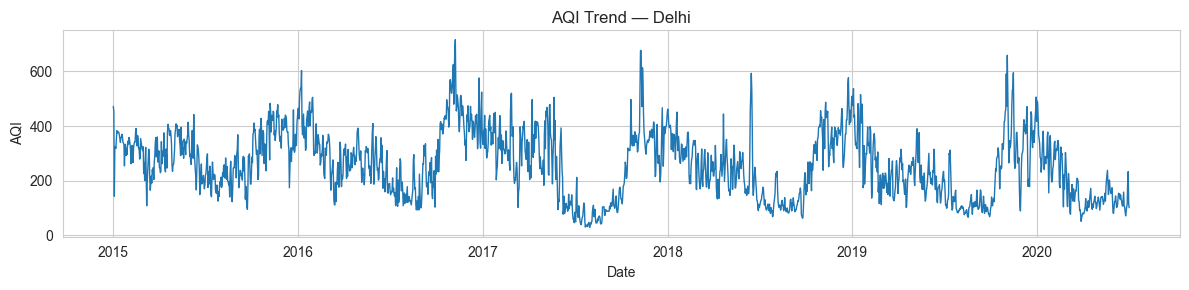

In [5]:
# Cell 5: single-city AQI trend
city = "Delhi" if "Delhi" in df['city'].unique() else df['city'].unique()[0]
city_df = df[df['city'] == city].sort_values("datetime")

plt.figure(figsize=(12,3))
plt.plot(city_df['datetime'], city_df['aqi'], linewidth=1)
plt.title(f"AQI Trend — {city}")
plt.xlabel("Date"); plt.ylabel("AQI")
plt.tight_layout()
plt.show()


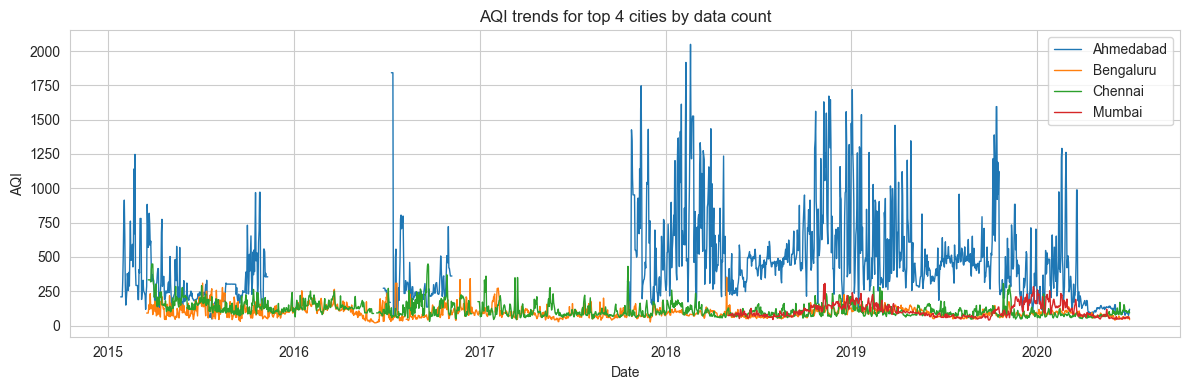

In [6]:
# Cell 6: multi-city overlay (select up to 4 cities with best coverage)
cities = df['city'].value_counts().nlargest(4).index.tolist()
plt.figure(figsize=(12,4))
for c in cities:
    temp = df[df['city']==c].sort_values('datetime')
    plt.plot(temp['datetime'], temp['aqi'], label=c, linewidth=1)
plt.title("AQI trends for top 4 cities by data count")
plt.xlabel("Date"); plt.ylabel("AQI")
plt.legend(); plt.tight_layout(); plt.show()


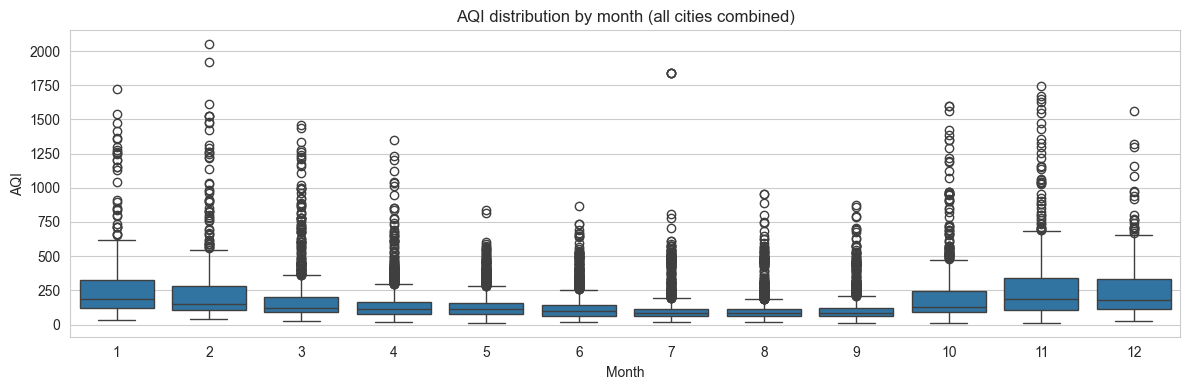

In [7]:
# Cell 7: monthly seasonality
df['month'] = df['datetime'].dt.month
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='month', y='aqi')
plt.title("AQI distribution by month (all cities combined)")
plt.xlabel("Month"); plt.ylabel("AQI"); plt.tight_layout(); plt.show()


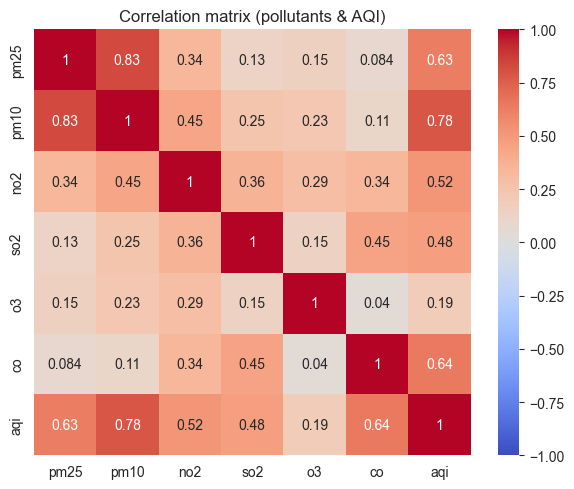

In [8]:
# Cell 8: correlation
cols = [c for c in ['pm25','pm10','no2','so2','o3','co','aqi'] if c in df.columns]
corr = df[cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation matrix (pollutants & AQI)")
plt.tight_layout(); plt.show()


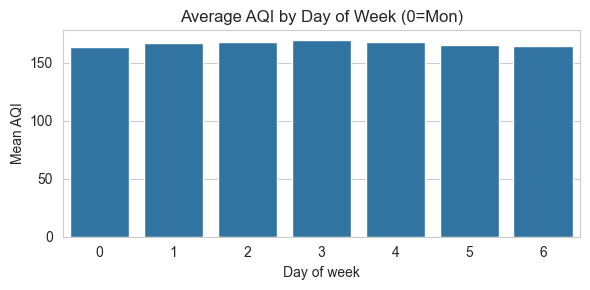

In [9]:
# Cell 9: day of week pattern
df['dow'] = df['datetime'].dt.dayofweek  # Monday=0
dow_mean = df.groupby('dow')['aqi'].mean()
plt.figure(figsize=(6,3))
sns.barplot(x=dow_mean.index, y=dow_mean.values)
plt.title("Average AQI by Day of Week (0=Mon)")
plt.xlabel("Day of week"); plt.ylabel("Mean AQI"); plt.tight_layout(); plt.show()


In [10]:
# Cell 10: save selected plot data if needed
# Example: save monthly median AQI for report
monthly_median = df.groupby('month')['aqi'].median().reset_index()
monthly_median.to_csv("../reports/monthly_median_aqi.csv", index=False)
print("Saved monthly median to ../reports/monthly_median_aqi.csv")


Saved monthly median to ../reports/monthly_median_aqi.csv
